In [1]:
# Importation des librairies

## Pour travailler les données
import numpy as np
import pandas as pd

## Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Pour l'imputation des valeurs manquantes
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer, KNNImputer

## Pour prétraiter les données
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

## Machine Learning
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score

## Importation des différents modèles de Machine learning
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.naive_bayes import GaussianNB


## Importation de Pipeline
from sklearn.pipeline import Pipeline

## Importation des différentes métriques
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, mean_absolute_error, mean_squared_error

# Explication du jeu de données

## Contexte

Il s'agit d'un jeu de données multivarié, ce qui implique l'utilisation de diverses variables mathématiques ou statistiques distinctes ainsi qu'une analyse numérique multivariée. Il se compose de 14 variable : l'âge, le sexe, le type de douleur thoracique, la pression artérielle au repos, le cholestérol sérique, la glycémie à jeun, les résultats de l'électrocardiogramme au repos, la fréquence cardiaque maximale atteinte, l'angine induite par l'effort, le « oldpeak » (sous-décalage du segment ST induit par l'effort par rapport au repos), la pente du segment ST au pic de l'effort, le nombre de vaisseaux principaux et la thalassémie. Bien que cette base de données comprenne initialement 76 variables, toutes les études publiées portent sur un sous-ensemble de 14 d'entre elles. À ce jour, la base de données de Cleveland est la seule utilisée par les chercheurs (ML). L'une des tâches principales associées à ce jeu de données consiste à prédire, à partir des variables d'un patient, si celui-ci souffre ou non d'une maladie cardiaque.

## Explication des variables 

- **`id`** Id unique pour chaque patient
- **`age`** Age du patient en années
- **`sex`** Sexe du patient :
  1. Male
  2. Female
- **`dataset`** Provenance du patient :
  * Cleveland
  * Hongrie
  * VA Long Beach
  * Suisse
- **`cp`** Indique le type de douleur thoracique :
  * Asymptotique
  * Non cardiaque
  * Douleur thoracique atypique
  * Douleur thoracique typique
- **`trestbps`** Tension artérielle au repos (en mmHg lors de l'hospitalisation)
- **`chol`** Cholestérol sérique (en mg/dL)
- **`fbs`** Indicateur si la glycémie à jeun est supérieure à 120mg/dL
- **`restecg`** Résultat de l'électrocardiogramme au repos :
  1. Normal
  2. Anomalie stt
  3. Hypertrophie ventriculaire gauche
- **`thalach`** Fréquence cardiaque maximale atteinte
- **`exang`** Indique si une angine est induite par l'effort
- **`oldpeak`** Sous-décalage du segment ST induite par l'exercice par rapport au repos
- **`slope`** Pente du segment ST au pic de l'effort :
  * Constante
  * Croissante
  * Décroissante
- **`ca`** Nombre de vaisseaux principaux colorés par fluoroscopie 
- **`thal`** thalassémie :
  * Normal
  * Défaut fixe
  * Défaut réversible
- **`num`** la variable cible :
  * 0 = Pas de maladie cardiaque
  * 1 = Maladie cardiaque légère
  * 2 = Maladie cardiaque modérée
  * 3 = Maladie cardiaque grave
  * 4 = Maladie cardiaque très grave
  

# Chargement des données et visualisation

In [2]:
#Chargement des données et visualisation
df = pd.read_csv("C:/Users/florian/Documents/fac/portfolio/heart_disease_uci.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


# Exploration des données

## Analyse Univariée

In [3]:
df.info() # Nous renseigne sur le type de données de chaque colonnes

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 156.4+ KB


On constate déjà que certaines variables ont des valeurs manquantes. En effet, la colonne **`id`** comporte 920 individus qui ne sont pas des null (donc 920 individus observés) alors que presque toutes la variables après **`trestbps`** contiennent des valeurs null. 

Nous nous en occuperons plus tard.

### Âge

D'abord nous allons étudier l'âge des individus

In [4]:
df["age"].describe()

count    920.000000
mean      53.510870
std        9.424685
min       28.000000
25%       47.000000
50%       54.000000
75%       60.000000
max       77.000000
Name: age, dtype: float64

On peut donc constater que la moyenne d'âge à laquelle les personnes sont susceptibles d'avoir des problèmes cardiaques est autour de 53 ans. De plus, les plus jeunes individus à avoir des problèmes cardiaques ont 28 ans et les plus agées ont 77 ans.

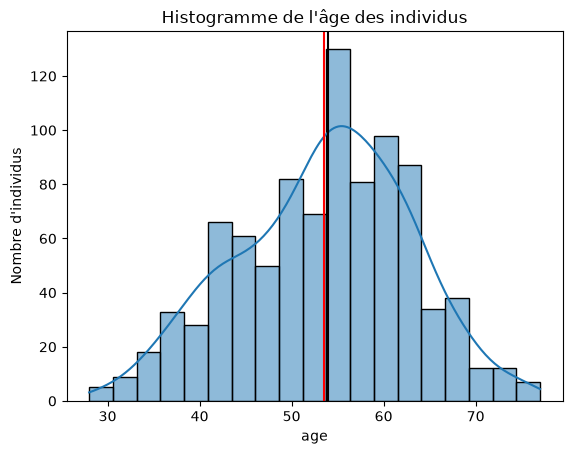

In [5]:
age_hist=sns.histplot(df['age'], kde=True)

age_hist.set_ylabel("Nombre d'individus")
age_hist.set_title("Histogramme de l'âge des individus")
plt.axvline(df['age'].mean(), color='Red') # Affiche la moyenne en rouge
plt.axvline(df['age'].median(), color='Black') # Affiche la médiane en noire
plt.show()

On remarque que les individus semblent être distribués selon une loi normale centrée autour de 53 ans pour l'âge. Nous observons également que l'âge moyen (en rouge) et l'âge médian (en noir) sont très proches l'un de l'autre (respectivement 53.51 ans contre 54 ans). Comme la médiane et la moyenne sont proches on peu supposé qu'il n'y a pas ou peu d'outliers.

### Sexe

Nous allons à présent nous concentrer sur le sexe pour observer les différences entre les hommes et les femmes observés.

In [6]:
df["sex"].value_counts()

sex
Male      726
Female    194
Name: count, dtype: int64

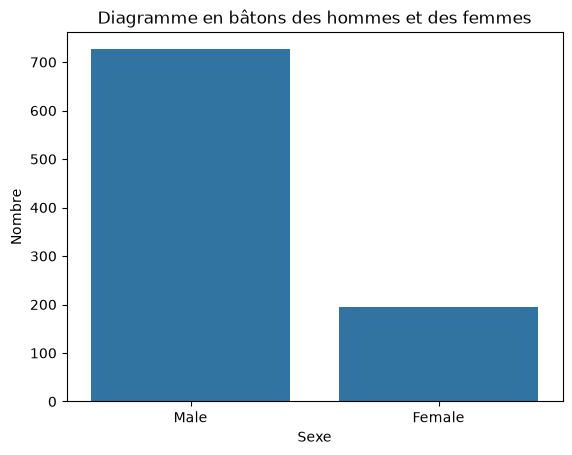

In [7]:
sns.countplot(data=df, x="sex")

plt.title("Diagramme en bâtons des hommes et des femmes")
plt.xlabel("Sexe")
plt.ylabel("Nombre")
plt.show()

In [8]:
male_count = 726
female_count = 194
total_count = 920

# Calcul du pourcentage d'hommes et de femmes dans les données
male_percentage = (male_count/total_count)*100
female_percentages = (female_count/total_count)*100

print(f"Pourcentage d'hommes dans les données : {male_percentage:.2f}%")
print(f"Pourcentage de femmes dans les données : {female_percentages:.2f}%")

# Difference
difference_percentage = ((male_count - female_count)/female_count) * 100
print(f"Il y a {difference_percentage:.2f}% plus d'hommes que de femmes dans les données")

Pourcentage d'hommes dans les données : 78.91%
Pourcentage de femmes dans les données : 21.09%
Il y a 274.23% plus d'hommes que de femmes dans les données


On remarque tout de suite que le pourcentage d'hommes dans le jeu de données est largement supérieur à celui des femmes.

### Dataset

La variable **`Dataset`** représente le lieu d'où provient l'individu observé.

In [9]:
df["dataset"].value_counts()

dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

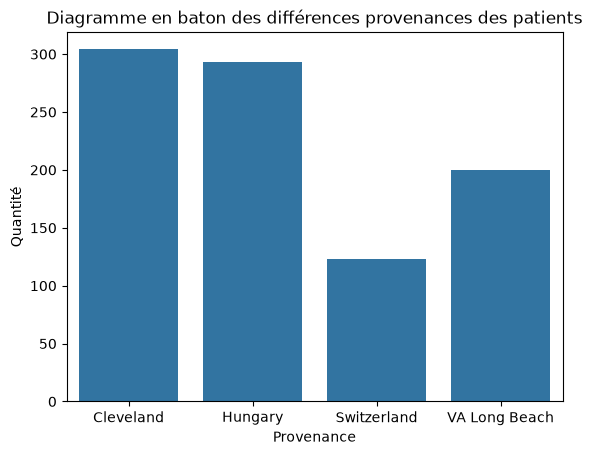

In [10]:
sns.countplot(data=df, x="dataset")

plt.title("Diagramme en baton des différences provenances des patients")
plt.xlabel("Provenance")
plt.ylabel("Quantité")
plt.show()

On remarque ici que les individus viennent de 4 endroits différents.

In [11]:
# # Calcul des différents pourcentages de la provenance des patients

print(f"Il y a {304/920*100: .2f}% des patients qui viennent de Cleveland")
print(f"Il y a {293/920*100: .2f}% des patients qui viennent d'Hongrie")
print(f"Il y a {200/920*100: .2f}% des patients qui viennent de VA Long Beach")
print(f"Il y a {123/920*100: .2f}% des patients qui viennent de Suisse")

Il y a  33.04% des patients qui viennent de Cleveland
Il y a  31.85% des patients qui viennent d'Hongrie
Il y a  21.74% des patients qui viennent de VA Long Beach
Il y a  13.37% des patients qui viennent de Suisse


### Cp

La variable **`cp`** représente la douleur thoracique ressentie,  à savoir : "asymptomatique", "non cardiaque", "angine de poitrine atypique" et "angine de poitrine typique".

In [12]:
df["cp"].value_counts()

cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

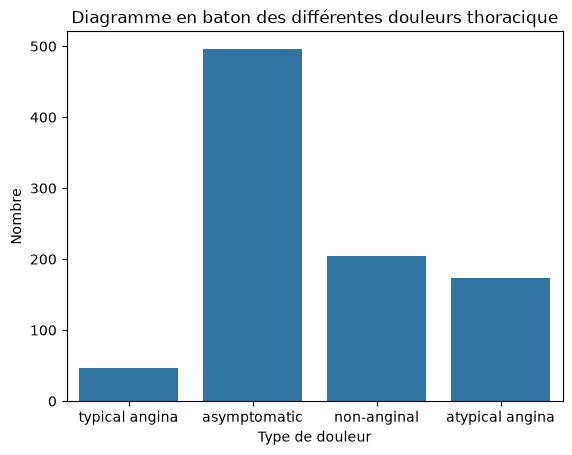

In [13]:
sns.countplot(data=df, x="cp")

plt.title("Diagramme en baton des différentes douleurs thoracique")
plt.xlabel("Type de douleur")
plt.ylabel("Nombre")
plt.show()

In [14]:
# Calcul des différents pourcentages des douleurs thoraciques observées

print(f"Il y a {496/920*100: .2f}% des patients qui ont des douleurs thoracique asymptotiques")
print(f"Il y a {204/920*100: .2f}% des patients qui ont des douleurs thoracique non cardiaque")
print(f"Il y a {174/920*100: .2f}% des patients qui ont des douleurs thoracique atypiques")
print(f"Il y a {46/920*100: .2f}% des patients qui ont des douleurs thoracique typiques")

Il y a  53.91% des patients qui ont des douleurs thoracique asymptotiques
Il y a  22.17% des patients qui ont des douleurs thoracique non cardiaque
Il y a  18.91% des patients qui ont des douleurs thoracique atypiques
Il y a  5.00% des patients qui ont des douleurs thoracique typiques


Plus de la moitié des individus sont asymptomatiques. 

### Num

On regarde la variable cible qui représente les différents problèmees cardiaques des individus

In [15]:
df["num"].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

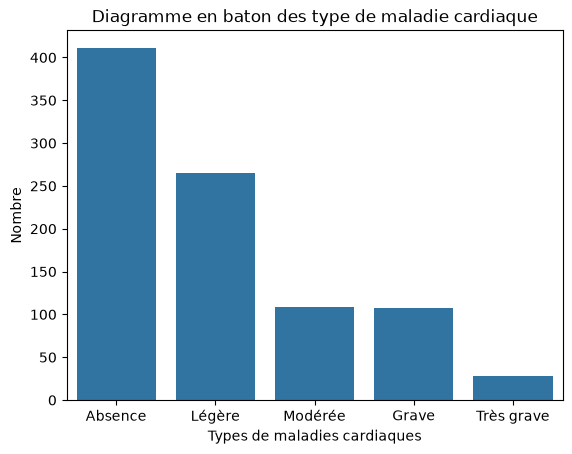

In [16]:
sns.countplot(data=df, x="num")
plt.xticks([0, 1, 2, 3, 4], ["Absence", "Légère", "Modérée", "Grave", "Très grave"])

plt.title("Diagramme en baton des type de maladie cardiaque")
plt.xlabel("Types de maladies cardiaques")
plt.ylabel("Nombre")
plt.show()

In [17]:
# Calcul des différents pourcentages des maladies cardiaques observées

print(f"Il y a {411/920*100: .2f}% des patients qui n'ont pas de maladies cardiaques")
print(f"Il y a {265/920*100: .2f}% des patients qui ont des maladies cardiaques légères")
print(f"Il y a {109/920*100: .2f}% des patients qui ont des maladies cardiaques graves")
print(f"Il y a {28/920*100: .2f}% des patients qui ont des maladies cardiaques très graves")

Il y a  44.67% des patients qui n'ont pas de maladies cardiaques
Il y a  28.80% des patients qui ont des maladies cardiaques légères
Il y a  11.85% des patients qui ont des maladies cardiaques graves
Il y a  3.04% des patients qui ont des maladies cardiaques très graves


On pourrait se dire que la majorité des patients sont des personnes qui n'ont pas de maladies cardiaques. Cependant, lors de l'arrivée en hôpital on cherche d'abord à savoir **S'ILS ONT** une maladie cardiaque avant de savoir de quel type il s'agît. On devrait donc comparer :

In [18]:
# Calcul des différents pourcentages des maladies cardiaques observées

print(f"Il y a {411/920*100: .2f}% des patients qui n'ont pas de maladies cardiaques")
print(f"Il y a {(920-411)/920*100: .2f}% des patients qui ont des maladies cardiaques")

Il y a  44.67% des patients qui n'ont pas de maladies cardiaques
Il y a  55.33% des patients qui ont des maladies cardiaques


On constate donc qu'il y a plus de patients avec des maladies cardiaques que de patients qui n'en ont pas.

## Analyse multivariée

Analyser les variables une à une est une bonne introduction, cependant une analyse de plusieurs variables ensemble donnera des résultats déjà plus exploitables.

### Etude de l'age des individus selon leur sexe

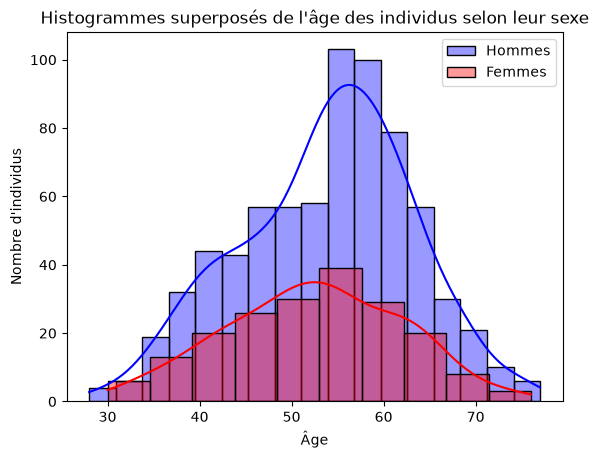

La moyenne d'âge pour les hommes est de :  53.79 ans
La médiane d'âge pour les hommes est de :  55.00 ans
La moyenne d'âge pour les femmes est de :  52.47 ans
La médiane d'âge pour les femmes est de :  53.00 ans


In [19]:
hommes = df[df["sex"] == "Male"]
femmes = df[df["sex"] == "Female"]

sns.histplot(hommes["age"], kde=True, color="blue", alpha=0.4, label="Hommes")
sns.histplot(femmes["age"], kde=True, color="red", alpha=0.4, label="Femmes")

plt.ylabel("Nombre d'individus")
plt.xlabel("Âge")
plt.title("Histogrammes superposés de l'âge des individus selon leur sexe")
plt.legend()

plt.show()

print(f"La moyenne d'âge pour les hommes est de : {hommes["age"].mean(): .2f} ans")
print(f"La médiane d'âge pour les hommes est de : {hommes["age"].median(): .2f} ans")
print(f"La moyenne d'âge pour les femmes est de : {femmes["age"].mean(): .2f} ans")
print(f"La médiane d'âge pour les femmes est de : {femmes["age"].median(): .2f} ans")

### Etude de la répartition homme-femme des maladies cardiaques en fonction de leur age

In [20]:
fig = px.box(df,x= "sex", y="age", title = "Boxplot du sexe en fonction de l'âge selon le type de maladie cardiaque", color = "num", 
             category_orders={"num": [0, 1, 2, 3, 4]})

fig.update_layout(title_x=0.5)
fig.show()

Pour les persoones qui n'ont pas de maladies cardiaques nous avons des résultats plutôt semblables entre les hommes et les femmes. La moyenne se situe à 51 ans, et le premier quartile est à 42 ans pour les hommes contre 44 ans pour les femmes.

Pour les personnes qui ont une maladie cardiaque légère, on constate peu d'écart également entre les hommes et les femmes.

Pour les personnes atteintes de maladies cardiaques modérées que 100 % des femmes ont ce genre de maladie avant 62 ans alors que chez les hommes certains en ont eu à plus de 70 ans. De plus, la médiane est de 59 ans chez les hommes contre 55 ans et demi chez les femmes.

Pour les personnes ayant une maladie cardiaque grave, un contraste est très présent entre les hommes et les femmes. Les hommes ont ce genre de problème majoritairement entre 39 ans et 77 ans alors que les femmes entre 55 ans et 66 ans.

Pour finir on voit très clairement une différence entre le nombre d'hommes et de femmes qui ont des problèmes cardiaques très graves. Pour les femmes ils arrivent tous entre 63 et 65 ans alors que pour les hommes la majorité des maladies cardiaque très graves sont entre 43 ans et 70 ans (sans tenir compte des valeurs extrêmes).

Par la suite nous allons regrouper toutes les maladies cardiaques ensemble pour comparer les patients qui ont une maladie cardiaque et ceux qui n'en ont pas.

### Etude de la répartition de l'age des hommes et des femmes s'ils ont une maladie cardiaque ou non

In [21]:
num_bin = df
num_bin["num"] = df["num"].replace([1, 2, 3, 4], 1)

fig = px.box(num_bin,x= "sex", y="age", title = "Boxplot du sexe en fonction de l'âge selon la présence de maladie cardiaque", color = "num")
fig.update_layout(title_x=0.5)
fig.show()

On remarque que les hommes commencent à avoir des maladies cardiaques plus tôt que les femmes, à savoir aux alentours de 35 ans pour les hommes contre 38 pour les femmes. Cependant 50% des cas se situent entre 51 ans et 62 ans que ce soit pour les hommes ou pour les femmes.

### Etude de l'age en fonction de la provenance

In [22]:
fig = px.histogram(data_frame=df, x='age', color= 'dataset', title = "Histogramme cumulatif de l'âge en fonction de la provenance")
fig.update_layout(title_x=0.5)
fig.show()

### Etude de l'age en fonction de la douleur thoracique

In [23]:
fig = px.histogram(data_frame=df, x='age', color= 'cp', title = "Histogramme cumulatif de l'âge en fonction de la douleur thoracique")
fig.update_layout(title_x=0.5)
fig.show()

### Etude de l'age en fonction de l'électrocardiogramme au repos

In [24]:
fig = px.histogram(data_frame=df, x='age', color= 'restecg', title = "Histogramme cumulatif de l'âge en fonction de l'électrocardiogramme au repos")
fig.update_layout(title_x=0.5)
fig.show()

### Etude de la provenance des patients en fonction de leur sexe

In [25]:
fig =px.bar(df, x='dataset', color='sex')
fig.show()

In [26]:
print (df.groupby('sex')['dataset'].value_counts())

sex     dataset      
Female  Cleveland         97
        Hungary           81
        Switzerland       10
        VA Long Beach      6
Male    Hungary          212
        Cleveland        207
        VA Long Beach    194
        Switzerland      113
Name: count, dtype: int64


# Nettoyage des données

Nous allons maintenant nettoyer le jeu de données et nous occupants dans un premier temps des valeurs manquantes. Nous allons d'abord regarder ce que donne le fait de supprimer toutes les valeurs manquantes du jeu de données.

In [27]:
# Variables avec le plus de valeurs manquantes
missing = df.isna().mean().sort_values(ascending=False)
print("Top colonnes avec NaN :")
print(missing.head(20))

Top colonnes avec NaN :
ca          0.664130
thal        0.528261
slope       0.335870
fbs         0.097826
oldpeak     0.067391
trestbps    0.064130
exang       0.059783
thalch      0.059783
chol        0.032609
restecg     0.002174
cp          0.000000
dataset     0.000000
id          0.000000
age         0.000000
sex         0.000000
num         0.000000
dtype: float64


Il y a donc 10 variables qui contiennent des valeurs manquantes. De plus, la plus importante, **`ca`** en contient 66%. Nous allons donc procéder à plus méthodes pour gérer ces données manquantes.

## Dropna

In [28]:
df2 = df.dropna()

df2.info()

<class 'pandas.DataFrame'>
Index: 299 entries, 0 to 748
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        299 non-null    int64  
 1   age       299 non-null    int64  
 2   sex       299 non-null    str    
 3   dataset   299 non-null    str    
 4   cp        299 non-null    str    
 5   trestbps  299 non-null    float64
 6   chol      299 non-null    float64
 7   fbs       299 non-null    object 
 8   restecg   299 non-null    str    
 9   thalch    299 non-null    float64
 10  exang     299 non-null    object 
 11  oldpeak   299 non-null    float64
 12  slope     299 non-null    str    
 13  ca        299 non-null    float64
 14  thal      299 non-null    str    
 15  num       299 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 55.6+ KB


On constate que l'on passe de 920 individus à 299. Il y a donc une perte beaucoup trop importante d'information pour garder cette méthode.

## Par imputation

Nous allons procéder par imputation de valeurs manquantes. Dans un premier temps nous allons utiliser la fonction **`IterativeImputer`** sur les variables de type float.

In [29]:
# Classification des variables 
missing_data_cols = df.isnull().sum()[df.isnull().sum()>0].index.tolist()
missing_data_cols

categorical_cols = ['thal', 'ca', 'slope', 'exang', 'restecg','fbs', 'cp', 'sex', 'num', 'fbs', 'exang']
numerical_cols = ['oldpeak', 'thalch', 'chol', 'trestbps', 'age']

In [30]:
for col in categorical_cols:
    print(f"Le pourcentage de valeur manquante dans la variable {col} est: {df[col].isnull().sum()/920*100: .2f}%")
    df[col] = df[col].fillna(df[col].mode()[0])

for col in numerical_cols:
    print(f"Le pourcentage de valeur manquante dans la variable {col} est: {df[col].isnull().sum()/920*100: .2f}%")
    df[col] = df[col].fillna(df[col].median())

Le pourcentage de valeur manquante dans la variable thal est:  52.83%
Le pourcentage de valeur manquante dans la variable ca est:  66.41%
Le pourcentage de valeur manquante dans la variable slope est:  33.59%
Le pourcentage de valeur manquante dans la variable exang est:  5.98%
Le pourcentage de valeur manquante dans la variable restecg est:  0.22%
Le pourcentage de valeur manquante dans la variable fbs est:  9.78%
Le pourcentage de valeur manquante dans la variable cp est:  0.00%
Le pourcentage de valeur manquante dans la variable sex est:  0.00%
Le pourcentage de valeur manquante dans la variable num est:  0.00%
Le pourcentage de valeur manquante dans la variable fbs est:  0.00%
Le pourcentage de valeur manquante dans la variable exang est:  0.00%
Le pourcentage de valeur manquante dans la variable oldpeak est:  6.74%
Le pourcentage de valeur manquante dans la variable thalch est:  5.98%
Le pourcentage de valeur manquante dans la variable chol est:  3.26%
Le pourcentage de valeur man

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  920 non-null    float64
 6   chol      920 non-null    float64
 7   fbs       920 non-null    object 
 8   restecg   920 non-null    str    
 9   thalch    920 non-null    float64
 10  exang     920 non-null    object 
 11  oldpeak   920 non-null    float64
 12  slope     920 non-null    str    
 13  ca        920 non-null    float64
 14  thal      920 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 160.2+ KB


On garde bien 920 individus après les imputations? On ne perd donc pas d'information.

Nous avons décidé d'imputer les variables catégorielles par l'élément le plus fréquement observé pour chaque variable ( exemple : si la variable **`sex`** avait des valeurs manquantes, comme il y a plus de 70% d'hommes, les valeurs manquantes auraient été changé par homme).

Pour les variables numériables numériques nous avons décidé d'imputer les variables manquantes par la valeur médiane (pour être moins impacté par les valeurs extrêmes par rapport à l'utilisation de la moyenne, même si ici ça n'aurait pas eu un grand impact).

# Machine learning

In [32]:
# Séparation du jeu de données en X et y
X = df.drop('num', axis=1)
y = df['num']

In [33]:
import warnings
warnings.filterwarnings('ignore')

In [34]:
def evaluate_classification_models(X, y, categorical_columns=None):

    
    X = X.copy()

    # Recherche des variables catégorielles
    if categorical_columns is None:
        categorical_columns = X.select_dtypes(
            include=['object', 'category']
        ).columns.tolist()

    # Recherche des variables numériques
    numerical_columns = X.select_dtypes(
        exclude=['object', 'category']
    ).columns.tolist()

    # Preprocessing des numériques
    numerical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])

    # Preprocessing des catégorielles
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Combine les preprocessing
    preprocessor = ColumnTransformer([
        ('num', numerical_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ])

    # Séparation des données en données train et test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Définition des modèles
    models = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "KNN": KNeighborsClassifier(),
        "NB": GaussianNB(),
        "SVM": SVC(),
        "Decision Tree": DecisionTreeClassifier(random_state=42),
        "Random Forest": RandomForestClassifier(random_state=42),
        "XGBoost": XGBClassifier(random_state=42),
        "GradientBoosting": GradientBoostingClassifier(random_state=42),
        "AdaBoost": AdaBoostClassifier(random_state=42)
    }

    # Entrainement et évalutaion

    resultats =[]
    best_model = None
    best_model_name = None
    best_recall =0.0

    
    for name, model in models.items():

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        # Cross validation
        
        scores = cross_val_score(pipeline, X_train, y_train, cv=5)

        # Prédiction de y
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        # Calcul des différentes métriques
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        cv_mean = scores.mean()


        resultats.append({
            'Model': name,
            "Cross-Validation moyenne": cv_mean,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall
        })

        if recall > best_recall:
            best_model = pipeline
            best_recall= recall
            best_model_name = name

        
    return resultats, best_model, best_model_name

In [35]:
# Utilisation de la fonction et affichage des résultats

results, best_model, choix = evaluate_classification_models(X, y)

df_score2 = pd.DataFrame(results)
print(df_score2)
print(f"\nLe choix du modèle est : {choix}")

                 Model  Cross-Validation moyenne  Accuracy  Precision  \
0  Logistic Regression                  0.846406  0.864130   0.865150   
1                  KNN                  0.781201  0.815217   0.818127   
2                   NB                  0.811133  0.869565   0.869429   
3                  SVM                  0.755396  0.755435   0.771978   
4        Decision Tree                  0.828820  0.842391   0.842193   
5        Random Forest                  0.860002  0.880435   0.882251   
6              XGBoost                  0.850496  0.885870   0.886348   
7     GradientBoosting                  0.865481  0.875000   0.877360   
8             AdaBoost                  0.874940  0.891304   0.891231   

     Recall  
0  0.864130  
1  0.815217  
2  0.869565  
3  0.755435  
4  0.842391  
5  0.880435  
6  0.885870  
7  0.875000  
8  0.891304  

Le choix du modèle est : AdaBoost


Le rappel, permet d'avoir une indication sur les faux négatifs. Comme nous sommes dans un cas médical et que les faux négatifs coûtent cher, nous allons prioriser le rappel comme métrique pour le choix du modèle. Ici, on observe que les 3 meilleurs modèles pour le rappel sont **`Logistic Regression`** (0.875), **`GradientBoosting`** (0.880) et **`AdaBoost`** (0.891)  ce qui implique qu'il y a peu de faux négatifs par rapport aux vrais.

Nous allons ensuite observer la moyenne des Cross-Validation. On constate que **`Logistic Regression`** n'est que le 5è meilleur avec cette métrique, nous ne le garderons pas. Nous allons choisir entre **`GradientBoosting`** (0.864) et **`AdaBoost`** (0.869).

Accuracy  pour les modèle **`GradientBoosting`** et **`AdaBoost`** est de 0.880 et 0.891, ce qui implique qu'ils classent de manière pertinente les patients qui doivent bien aller dans ces catégories.

La précision c'est le fait de comparer les vrais positifs avec toutes les personnes classées positives (vraies ou fausses). On peut constater que c'est **`AdaBoost`** qui a le meilleur score de precision avec 0.891. La précision permet de controler les Faux positifs, plus la précision est importante, moins il y a de Faux positifs.

Après observation des résultats des métriques on décide de garder **`AdaBoost`**.

In [36]:
def hyperparameter_tuning(X, y, models, categorical_columns=None):

    # Recherche des variables catégorielles
    if categorical_columns is None:
        categorical_columns = X.select_dtypes(
            include=['object', 'category']
        ).columns.tolist()

    # Recherche des variables numériques
    numerical_columns = X.select_dtypes(
        exclude=['object', 'category']
    ).columns.tolist()

    # Preprocessing numérique
    numerical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='median'))
    ])

    # Preprocessing catégoriel
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ])

    # Combine les preprocessing
    preprocessor = ColumnTransformer([
        ('num', numerical_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ])

    # Séparation des données en données train et test
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Dictionnaire des résultats
    results = {}

    # Optimisation des modèles
    for model_name, model in models.items():

        # Grille des hyperparamètres
        param_grid = {}
        if model_name == 'Logistic Regression':param_grid = {'model__C': [0.1, 1, 10, 100]}

        elif model_name == 'KNN':param_grid = {'model__n_neighbors': [3, 5, 7, 9]}

        elif model_name == 'NB':param_grid = {'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]}

        elif model_name == 'SVM':param_grid = {'model__C': [0.1, 1, 10, 100], 'model__gamma': [0.1, 1, 10, 100]}

        elif model_name == 'Decision Tree':param_grid = {'model__max_depth': [None, 10, 20, 30], 'model__min_samples_split': [2, 5, 10]}

        elif model_name == 'Random Forest':param_grid = {'model__n_estimators': [100, 200, 300], 'model__max_depth': [None, 10, 20, 30],
                                                         'model__min_samples_split': [2, 5, 10]}

        elif model_name == 'XGBoost':param_grid = {'model__learning_rate': [0.01, 0.1, 0.2], 'model__n_estimators': [100, 200, 300],
                                                   'model__max_depth': [3, 5, 7]}

        elif model_name == 'GradientBoosting':param_grid = {'model__learning_rate': [0.01, 0.1, 0.2], 'model__n_estimators': [100, 200, 300],
                                                            'model__max_depth': [3, 5, 7]}

        elif model_name == 'AdaBoost':param_grid = {'model__learning_rate': [0.01, 0.1, 0.2], 'model__n_estimators': [50, 100, 200]}

        # Pipeline
        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        # GridSearchCV
        grid_search = GridSearchCV(
            pipeline,
            param_grid,
            cv=5,
            scoring='accuracy'
        )

        grid_search.fit(X_train, y_train)

        # Meilleur modèle
        best_model = grid_search.best_estimator_

        # Prédiction de y
        y_pred = best_model.predict(X_test)

        # Calcul des métriques
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        cv = grid_search.best_score_

        # Stockage
        results[model_name] = {
            'best_params': grid_search.best_params_,
            'cv_mean': cv,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'best_model': best_model
        }

    return results

In [37]:
# Dictionnaire des modèles
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "SVM": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(),
    "GradientBoosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier()
}

# Application
results = hyperparameter_tuning(X, y, models)

In [38]:
# Création et affichage du tableau
df_results = pd.DataFrame([
    {
        'Model': model_name,
        'Best hyperparameters': result['best_params'],
        'CV score': result['cv_mean'],
        'Accuracy': result['accuracy'],
        'Precision': result['precision'],
        'Recall': result['recall']
    }
    for model_name, result in results.items()
])

df_results

,Model,Best hyperparameters,CV score,Accuracy,Precision,Recall
0,Logistic Regression,{'model__C': 1},0.843685,0.864130,0.866261,0.864130
1,KNN,{'model__n_neighbors': 7},0.783903,0.826087,0.829356,0.826087
2,NB,{'model__var_smoothing': 1e-06},0.826071,0.864130,0.864336,0.864130
3,SVM,"{'model__C': 1, 'model__gamma': 0.1}",0.558421,0.554348,0.307302,0.554348
4,Decision Tree,"{'model__max_depth': 20, 'model__min_samples_s...",0.824756,0.815217,0.815807,0.815217
5,Random Forest,"{'model__max_depth': 20, 'model__min_samples_s...",0.873616,0.885870,0.888459,0.885870
6,XGBoost,"{'model__learning_rate': 0.01, 'model__max_dep...",0.876347,0.896739,0.899558,0.896739
7,GradientBoosting,"{'model__learning_rate': 0.01, 'model__max_dep...",0.872247,0.885870,0.888459,0.885870
8,AdaBoost,"{'model__learning_rate': 0.2, 'model__n_estima...",0.880419,0.891304,0.893313,0.891304


Ici, on observe que les 3 meilleurs modèles pour le rappel sont **`XGBoost`** (0.897), **`Random Forest`** (0.885) et **`AdaBoost`** (0.891)  ce qui implique qu'il y a peu de faux négatifs par rapport aux vrais.

Nous allons ensuite observer le score des Cross-Validation. On constate que  **`AdaBoost`** (0.880) a le meilleur score suivi de **`Random Forest`** (0.877) puis **`XGBoost`** (0.876).

Accuracy  pour les modèle **`AdaBoost`**, **`XGBoost`** et **`Random Forest`** est respectivement de 0.891, 0.897 et 0.886, ce qui implique qu'ils classent de manière pertinente les patients qui doivent bien aller dans ces catégories.

On peut constater que c'est **`XGBoostt`** qui a le meilleur score de precision avec 0.899. On remarque que les deux autres ne sont pas très loin derrière non plus (**`AdaBoost`** est à 0.893 et **`Random Forest`** est à 0.888).

Après observation des résultats des métriques on décide de garder **`XGBoost`**.